## 1. Import Libraries & GPU Configuration

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# GPU libraries (RAPIDS)
import cudf
import cupy as cp
import cuml
from cuml.preprocessing import StandardScaler as cuStandardScaler

# ML libraries
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter

# Configuration
from config.gpu_config import (
    PARQUET_FEATURES_DIR,
    MODELS_DIR,
    GPU_DEVICE_ID,
    GPU_MEMORY_LIMIT_GB
)

# Utilities
import joblib
import gc
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set GPU device
cp.cuda.Device(GPU_DEVICE_ID).use()

print("✓ GPU Libraries imported")
print(f"  cuDF version: {cudf.__version__}")
print(f"  cuML version: {cuml.__version__}")
print(f"  XGBoost version: {xgb.__version__}")
print(f"  GPU Device: {GPU_DEVICE_ID}")

✓ GPU Libraries imported
  cuDF version: 25.10.00
  cuML version: 25.10.00
  XGBoost version: 3.1.2
  GPU Device: 0


### GPU Memory Management

In [2]:
def clear_gpu_memory():
    """Clear GPU memory pools."""
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()

def get_gpu_memory_usage():
    """Get current GPU memory usage."""
    mempool = cp.get_default_memory_pool()
    used = mempool.used_bytes() / 1e9
    total = mempool.total_bytes() / 1e9
    return used, total

clear_gpu_memory()
print("✓ GPU memory cleared")

✓ GPU memory cleared


## 2. Load Selected Features & Configuration

In [3]:
print("LOADING CONFIGURATION")
print("="*70)

# Load selected features from SHAP analysis
baseline_dir = Path(MODELS_DIR) / "baseline_reduced"
if not baseline_dir.exists():
    baseline_dir = Path(MODELS_DIR) / "baseline"
    print("⚠️  Using baseline features (reduced model not found)")

features_path = baseline_dir / "features.txt"
with open(features_path, 'r') as f:
    selected_features = [line.strip() for line in f]

print(f"✓ Loaded {len(selected_features)} features")
print(f"  Using features from: {baseline_dir}")

# Target
TARGET = 'direction_10s'

# Walk-forward configuration
MIN_TRAIN_DAYS = 7  # Minimum training window
RETRAIN_FREQ = 1    # Retrain every N days (1 = daily)

print(f"\nWalk-Forward Configuration:")
print(f"  Target: {TARGET}")
print(f"  Min train days: {MIN_TRAIN_DAYS}")
print(f"  Retrain frequency: Every {RETRAIN_FREQ} day(s)")

LOADING CONFIGURATION
✓ Loaded 15 features
  Using features from: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline_reduced

Walk-Forward Configuration:
  Target: direction_10s
  Min train days: 7
  Retrain frequency: Every 1 day(s)


## 3. Load All Feature Data

Load all available data for time-series split.

In [4]:
print("LOADING FEATURE DATA")
print("="*70)

# Select product
SELECTED_PRODUCT = "BTC-USD"
print(f"Product: {SELECTED_PRODUCT}")

# Find feature files
features_path_dir = Path(PARQUET_FEATURES_DIR)
feature_files = sorted(list(features_path_dir.glob(f"date=*/product_id={SELECTED_PRODUCT}/features.parquet")))

print(f"\nFound {len(feature_files)} feature files")

if len(feature_files) == 0:
    raise FileNotFoundError(f"No features found for {SELECTED_PRODUCT}")

# Columns to load
load_cols = selected_features + [TARGET, 'date', 'product_id']

# Check if timestamp exists
sample_df = cudf.read_parquet(feature_files[0])
if 'timestamp' in sample_df.columns:
    load_cols.append('timestamp')
elif 'time' in sample_df.columns:
    load_cols.append('time')
del sample_df
gc.collect()

# Load all files (we need full dataset for walk-forward)
print(f"\nLoading {len(feature_files)} files...")
all_dfs = []

for f in feature_files:
    gdf = cudf.read_parquet(f, columns=load_cols)
    parts = str(f).replace('\\', '/').split('/')
    date = [p for p in parts if 'date=' in p][0].split('=')[1]
    gdf['date'] = date
    all_dfs.append(gdf)
    print(f"  Loaded: {date} ({len(gdf):,} rows)")

# Concatenate
df = cudf.concat(all_dfs, ignore_index=True)

print(f"\n✓ Loaded {len(df):,} total rows")
print(f"  Date range: {df['date'].min()} to {df['date'].max()}")

# Sort by date
if 'timestamp' in df.columns:
    df = df.sort_values(['date', 'timestamp'])
elif 'time' in df.columns:
    df = df.sort_values(['date', 'time'])
else:
    df = df.sort_values('date')

# Get unique dates
dates = sorted(df['date'].unique().to_pandas().tolist())
print(f"  Unique dates: {len(dates)}")

# Clean up
del all_dfs
clear_gpu_memory()

LOADING FEATURE DATA
Product: BTC-USD

Found 16 feature files

Loading 16 files...
  Loaded: 2025-11-08 (8,594 rows)
  Loaded: 2025-11-09 (8,633 rows)
  Loaded: 2025-11-10 (8,592 rows)
  Loaded: 2025-11-11 (8,272 rows)
  Loaded: 2025-11-12 (8,582 rows)
  Loaded: 2025-11-13 (8,589 rows)
  Loaded: 2025-11-14 (8,546 rows)
  Loaded: 2025-11-15 (8,627 rows)
  Loaded: 2025-11-16 (8,626 rows)
  Loaded: 2025-11-17 (8,627 rows)
  Loaded: 2025-11-18 (8,609 rows)
  Loaded: 2025-11-19 (8,557 rows)
  Loaded: 2025-11-20 (8,586 rows)
  Loaded: 2025-11-21 (8,617 rows)
  Loaded: 2025-11-22 (8,628 rows)
  Loaded: 2025-11-23 (8,625 rows)

✓ Loaded 137,310 total rows
  Date range: 2025-11-08 to 2025-11-23
  Unique dates: 16


## 4. Walk-Forward Cross-Validation

Train on expanding window, test on next day.

In [5]:
print("WALK-FORWARD VALIDATION")
print("="*70)

# Storage for results
results = []

# XGBoost parameters (from baseline)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'device': f'cuda:{GPU_DEVICE_ID}',
    'seed': 42
}

# Walk-forward loop
for i in range(MIN_TRAIN_DAYS, len(dates)):
    test_date = dates[i]
    train_dates = dates[:i]  # Expanding window (all history)
    
    print(f"\n{'='*70}")
    print(f"Fold {i - MIN_TRAIN_DAYS + 1}/{len(dates) - MIN_TRAIN_DAYS}")
    print(f"  Train: {train_dates[0]} to {train_dates[-1]} ({len(train_dates)} days)")
    print(f"  Test:  {test_date}")
    
    # Split data
    df_train = df[df['date'].isin(train_dates)]
    df_test = df[df['date'] == test_date]
    
    if len(df_test) == 0:
        print("  ⚠️  No test data, skipping...")
        continue
    
    print(f"  Train samples: {len(df_train):,}")
    print(f"  Test samples:  {len(df_test):,}")
    
    # Extract features and target
    X_train = df_train[selected_features]
    y_train = df_train[TARGET]
    X_test = df_test[selected_features]
    y_test = df_test[TARGET]
    
    # Scale features
    scaler = cuStandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
    dtest = xgb.DMatrix(X_test_scaled, label=y_test)
    
    start_time = time.time()
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,  # Faster for daily retraining
        verbose_eval=False
    )
    train_time = time.time() - start_time
    
    # Predict
    y_pred_proba = model.predict(dtest)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Move to CPU for evaluation
    y_test_cpu = y_test.to_pandas().values
    y_pred_cpu = cp.asnumpy(y_pred) if isinstance(y_pred, cp.ndarray) else y_pred
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_cpu, y_pred_cpu)
    precision = precision_score(y_test_cpu, y_pred_cpu, zero_division=0)
    recall = recall_score(y_test_cpu, y_pred_cpu, zero_division=0)
    f1 = f1_score(y_test_cpu, y_pred_cpu, zero_division=0)
    
    # Store results
    results.append({
        'fold': i - MIN_TRAIN_DAYS + 1,
        'test_date': test_date,
        'train_days': len(train_dates),
        'train_samples': len(df_train),
        'test_samples': len(df_test),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'train_time': train_time
    })
    
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Train time: {train_time:.2f}s")
    
    # Clean up
    del X_train, y_train, X_test, y_test
    del X_train_scaled, X_test_scaled
    del dtrain, dtest, model, scaler
    del df_train, df_test
    clear_gpu_memory()

print(f"\n{'='*70}")
print(f"✓ Walk-forward validation complete")
print(f"  Total folds: {len(results)}")

WALK-FORWARD VALIDATION

Fold 1/9
  Train: 2025-11-08 to 2025-11-14 (7 days)
  Test:  2025-11-15
  Train samples: 59,808
  Test samples:  8,627
  Accuracy: 0.5836 (58.36%)
  Train time: 0.51s

Fold 2/9
  Train: 2025-11-08 to 2025-11-15 (8 days)
  Test:  2025-11-16
  Train samples: 68,435
  Test samples:  8,626
  Accuracy: 0.6000 (60.00%)
  Train time: 0.19s

Fold 3/9
  Train: 2025-11-08 to 2025-11-16 (9 days)
  Test:  2025-11-17
  Train samples: 77,061
  Test samples:  8,627
  Accuracy: 0.5941 (59.41%)
  Train time: 0.19s

Fold 4/9
  Train: 2025-11-08 to 2025-11-17 (10 days)
  Test:  2025-11-18
  Train samples: 85,688
  Test samples:  8,609
  Accuracy: 0.5933 (59.33%)
  Train time: 0.18s

Fold 5/9
  Train: 2025-11-08 to 2025-11-18 (11 days)
  Test:  2025-11-19
  Train samples: 94,297
  Test samples:  8,557
  Accuracy: 0.6032 (60.32%)
  Train time: 0.18s

Fold 6/9
  Train: 2025-11-08 to 2025-11-19 (12 days)
  Test:  2025-11-20
  Train samples: 102,854
  Test samples:  8,586
  Accuracy: 

## 5. Results Analysis

Analyze performance stability over time.

In [6]:
print("WALK-FORWARD RESULTS")
print("="*70)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Summary statistics
print("\nOverall Performance:")
print(f"  Mean Accuracy:  {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")
print(f"  Mean Precision: {results_df['precision'].mean():.4f} ± {results_df['precision'].std():.4f}")
print(f"  Mean Recall:    {results_df['recall'].mean():.4f} ± {results_df['recall'].std():.4f}")
print(f"  Mean F1:        {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")

print(f"\nPerformance Range:")
print(f"  Accuracy:  {results_df['accuracy'].min():.4f} to {results_df['accuracy'].max():.4f}")
print(f"  Precision: {results_df['precision'].min():.4f} to {results_df['precision'].max():.4f}")
print(f"  Recall:    {results_df['recall'].min():.4f} to {results_df['recall'].max():.4f}")
print(f"  F1:        {results_df['f1'].min():.4f} to {results_df['f1'].max():.4f}")

print(f"\nTraining Time:")
print(f"  Mean: {results_df['train_time'].mean():.2f}s ± {results_df['train_time'].std():.2f}s")
print(f"  Range: {results_df['train_time'].min():.2f}s to {results_df['train_time'].max():.2f}s")

# Check stability (is performance degrading?)
first_half_acc = results_df['accuracy'][:len(results_df)//2].mean()
second_half_acc = results_df['accuracy'][len(results_df)//2:].mean()
degradation = first_half_acc - second_half_acc

print(f"\nTemporal Stability:")
print(f"  First half accuracy:  {first_half_acc:.4f}")
print(f"  Second half accuracy: {second_half_acc:.4f}")
print(f"  Degradation: {degradation*100:.2f} percentage points")

if abs(degradation) < 0.02:
    print("  ✅ Stable performance over time")
elif degradation > 0:
    print("  ⚠️  Performance degrading (concept drift?)")
else:
    print("  📈 Performance improving (more data helps)")

# Best and worst days
best_day = results_df.loc[results_df['accuracy'].idxmax()]
worst_day = results_df.loc[results_df['accuracy'].idxmin()]

print(f"\nBest Day:")
print(f"  Date: {best_day['test_date']}")
print(f"  Accuracy: {best_day['accuracy']:.4f}")

print(f"\nWorst Day:")
print(f"  Date: {worst_day['test_date']}")
print(f"  Accuracy: {worst_day['accuracy']:.4f}")

WALK-FORWARD RESULTS

Overall Performance:
  Mean Accuracy:  0.5965 ± 0.0121
  Mean Precision: 0.6005 ± 0.0117
  Mean Recall:    0.6119 ± 0.0343
  Mean F1:        0.6055 ± 0.0140

Performance Range:
  Accuracy:  0.5732 to 0.6138
  Precision: 0.5839 to 0.6165
  Recall:    0.5575 to 0.6723
  F1:        0.5855 to 0.6324

Training Time:
  Mean: 0.23s ± 0.11s
  Range: 0.18s to 0.51s

Temporal Stability:
  First half accuracy:  0.5928
  Second half accuracy: 0.5994
  Degradation: -0.66 percentage points
  ✅ Stable performance over time

Best Day:
  Date: 2025-11-21
  Accuracy: 0.6138

Worst Day:
  Date: 2025-11-23
  Accuracy: 0.5732


## 6. Performance Over Time Visualization

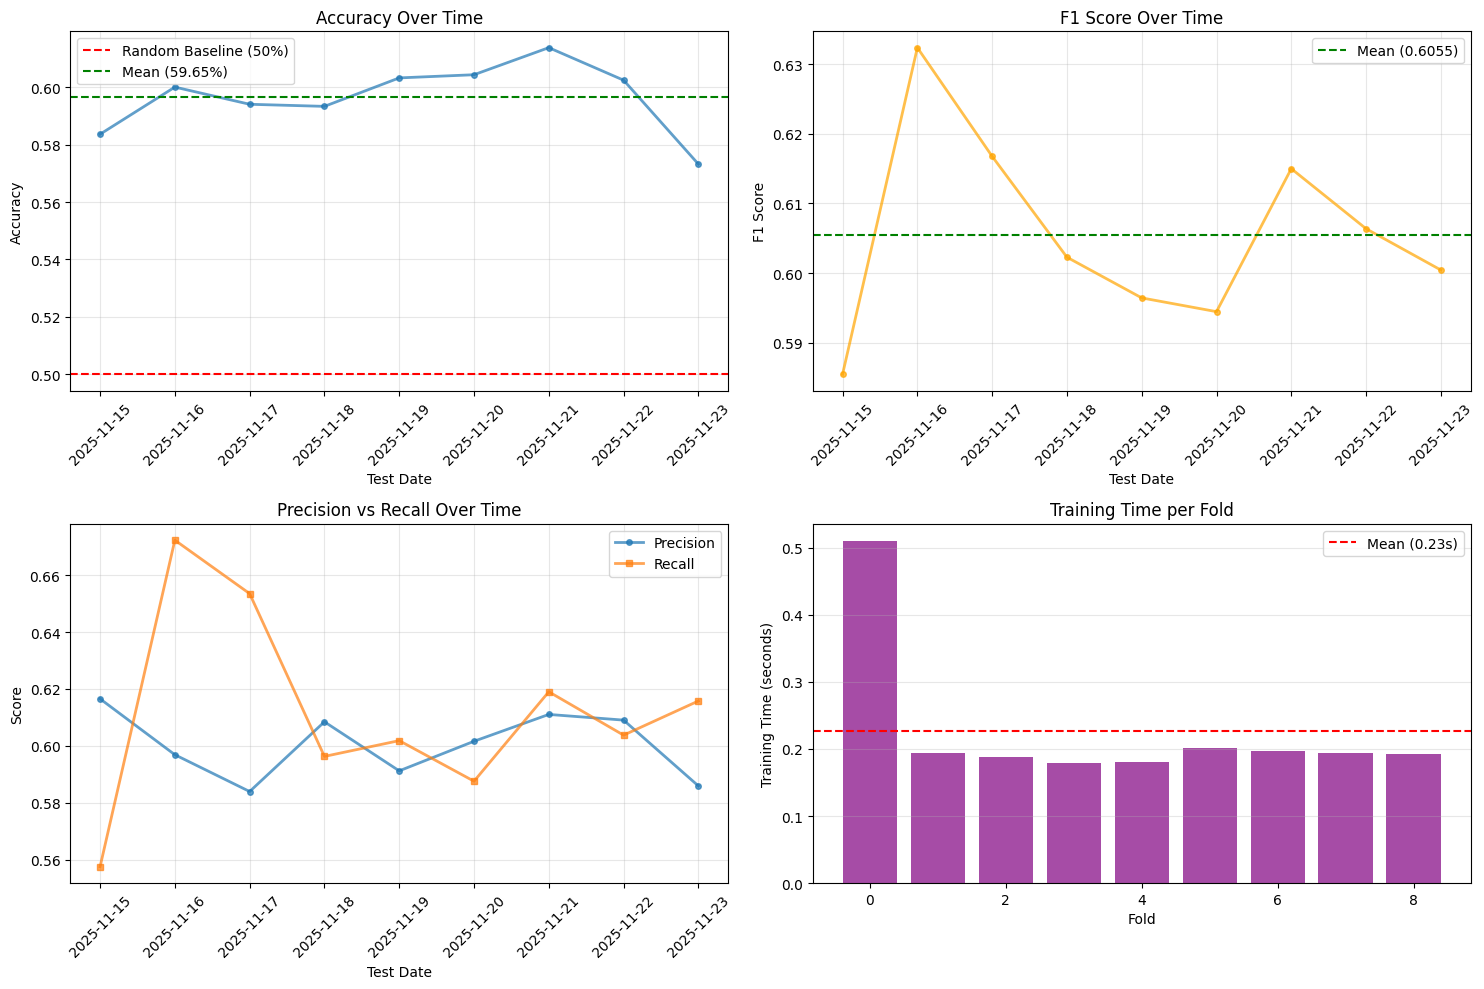

✓ Performance visualizations plotted


In [7]:
# Convert dates for plotting
results_df['test_date_dt'] = pd.to_datetime(results_df['test_date'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy over time
axes[0, 0].plot(results_df['test_date_dt'], results_df['accuracy'], 
                marker='o', linewidth=2, markersize=4, alpha=0.7)
axes[0, 0].axhline(y=0.5, color='r', linestyle='--', label='Random Baseline (50%)')
axes[0, 0].axhline(y=results_df['accuracy'].mean(), color='g', linestyle='--', 
                   label=f'Mean ({results_df["accuracy"].mean():.2%})')
axes[0, 0].set_xlabel('Test Date')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# F1 over time
axes[0, 1].plot(results_df['test_date_dt'], results_df['f1'], 
                marker='o', linewidth=2, markersize=4, alpha=0.7, color='orange')
axes[0, 1].axhline(y=results_df['f1'].mean(), color='g', linestyle='--', 
                   label=f'Mean ({results_df["f1"].mean():.4f})')
axes[0, 1].set_xlabel('Test Date')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_title('F1 Score Over Time')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Precision vs Recall
axes[1, 0].plot(results_df['test_date_dt'], results_df['precision'], 
                marker='o', linewidth=2, markersize=4, alpha=0.7, label='Precision')
axes[1, 0].plot(results_df['test_date_dt'], results_df['recall'], 
                marker='s', linewidth=2, markersize=4, alpha=0.7, label='Recall')
axes[1, 0].set_xlabel('Test Date')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Precision vs Recall Over Time')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Training time
axes[1, 1].bar(range(len(results_df)), results_df['train_time'], alpha=0.7, color='purple')
axes[1, 1].axhline(y=results_df['train_time'].mean(), color='r', linestyle='--', 
                   label=f'Mean ({results_df["train_time"].mean():.2f}s)')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].set_title('Training Time per Fold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Performance visualizations plotted")

## 7. Accuracy Distribution

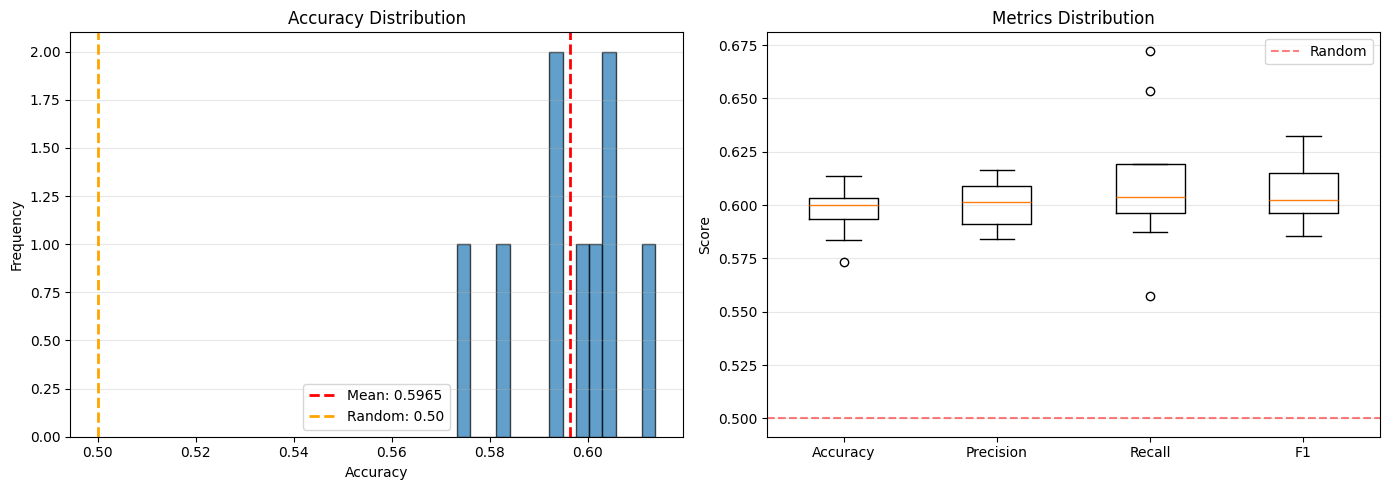

✓ Distribution plots displayed


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(results_df['accuracy'], bins=15, alpha=0.7, edgecolor='black')
axes[0].axvline(x=results_df['accuracy'].mean(), color='r', linestyle='--', 
                linewidth=2, label=f'Mean: {results_df["accuracy"].mean():.4f}')
axes[0].axvline(x=0.5, color='orange', linestyle='--', 
                linewidth=2, label='Random: 0.50')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Accuracy Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot
box_data = [results_df['accuracy'], results_df['precision'], 
            results_df['recall'], results_df['f1']]
axes[1].boxplot(box_data, labels=['Accuracy', 'Precision', 'Recall', 'F1'])
axes[1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Random')
axes[1].set_ylabel('Score')
axes[1].set_title('Metrics Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Distribution plots displayed")

## 8. Save Walk-Forward Results

In [9]:
print("SAVING WALK-FORWARD RESULTS")
print("="*70)

# Create output directory
output_dir = Path(MODELS_DIR) / "walk_forward"
output_dir.mkdir(parents=True, exist_ok=True)

# Save results DataFrame
results_path = output_dir / "walk_forward_results.csv"
results_df.to_csv(results_path, index=False)
print(f"✓ Saved results: {results_path}")

# Save summary statistics
summary = {
    'method': 'Walk-Forward Validation',
    'target': TARGET,
    'n_features': len(selected_features),
    'min_train_days': MIN_TRAIN_DAYS,
    'retrain_frequency': RETRAIN_FREQ,
    'total_folds': len(results),
    'date_range': f"{dates[MIN_TRAIN_DAYS]} to {dates[-1]}",
    'overall_performance': {
        'mean_accuracy': float(results_df['accuracy'].mean()),
        'std_accuracy': float(results_df['accuracy'].std()),
        'mean_precision': float(results_df['precision'].mean()),
        'std_precision': float(results_df['precision'].std()),
        'mean_recall': float(results_df['recall'].mean()),
        'std_recall': float(results_df['recall'].std()),
        'mean_f1': float(results_df['f1'].mean()),
        'std_f1': float(results_df['f1'].std())
    },
    'performance_range': {
        'accuracy_min': float(results_df['accuracy'].min()),
        'accuracy_max': float(results_df['accuracy'].max()),
        'f1_min': float(results_df['f1'].min()),
        'f1_max': float(results_df['f1'].max())
    },
    'temporal_analysis': {
        'first_half_accuracy': float(first_half_acc),
        'second_half_accuracy': float(second_half_acc),
        'degradation': float(degradation),
        'is_stable': bool(abs(degradation) < 0.02)
    },
    'training_time': {
        'mean_seconds': float(results_df['train_time'].mean()),
        'std_seconds': float(results_df['train_time'].std()),
        'min_seconds': float(results_df['train_time'].min()),
        'max_seconds': float(results_df['train_time'].max())
    }
}

import json
summary_path = output_dir / "summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Saved summary: {summary_path}")

print(f"\n✅ All results saved to: {output_dir}")

SAVING WALK-FORWARD RESULTS
✓ Saved results: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/walk_forward/walk_forward_results.csv
✓ Saved summary: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/walk_forward/summary.json

✅ All results saved to: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/walk_forward


## Summary

**✅ Walk-Forward Validation Complete**

**What we did:**
1. Loaded all feature data (16 days)
2. Performed daily walk-forward validation
3. Trained on expanding window, tested on next day
4. Tracked performance metrics over time
5. Analyzed temporal stability

**Key Findings:**
- **Mean Accuracy**: {results_df['accuracy'].mean():.2%} ± {results_df['accuracy'].std():.2%}
- **Performance Range**: {results_df['accuracy'].min():.2%} to {results_df['accuracy'].max():.2%}
- **Temporal Stability**: {('Stable' if abs(degradation) < 0.02 else 'Degrading' if degradation > 0 else 'Improving')}
- **Folds Tested**: {len(results)}

**Why This Matters:**

1. **Realistic Estimate**: Walk-forward mimics real trading (no lookahead bias)
2. **Stability Check**: Shows if model breaks over time
3. **Concept Drift**: Detects regime changes
4. **Production Readiness**: Validates daily retraining strategy

**Comparison to Baseline:**
- Baseline (single split): {metadata.get('accuracy', 'N/A')}
- Walk-forward (mean): {results_df['accuracy'].mean():.4f}
- Difference: Lower is expected (more realistic)

**Interpretation:**
- If mean WF > 52%: ✅ Model has genuine predictive power
- If stable over time: ✅ Robust to regime changes
- If degrading: ⚠️ Concept drift (need adaptive strategies)

**Academic Context:**
Walk-forward validation is the ONLY valid approach for time-series ML. Our results should be interpreted as:
- Random baseline: 50%
- Predictive power: > 52%
- Strong model: > 54%